<a href="https://colab.research.google.com/github/HanifFaishalH/PCVK25_3F_15/blob/master/Week5_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 5 - Histogram, Histogram Equalization, Dithering

Nama : Hanif Faishal Hilmi

Kelas : TI-3F

NIM : 2341720116

## Percobaan D1 HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Import library yang akan digunakan

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3. Membuat histogram citra

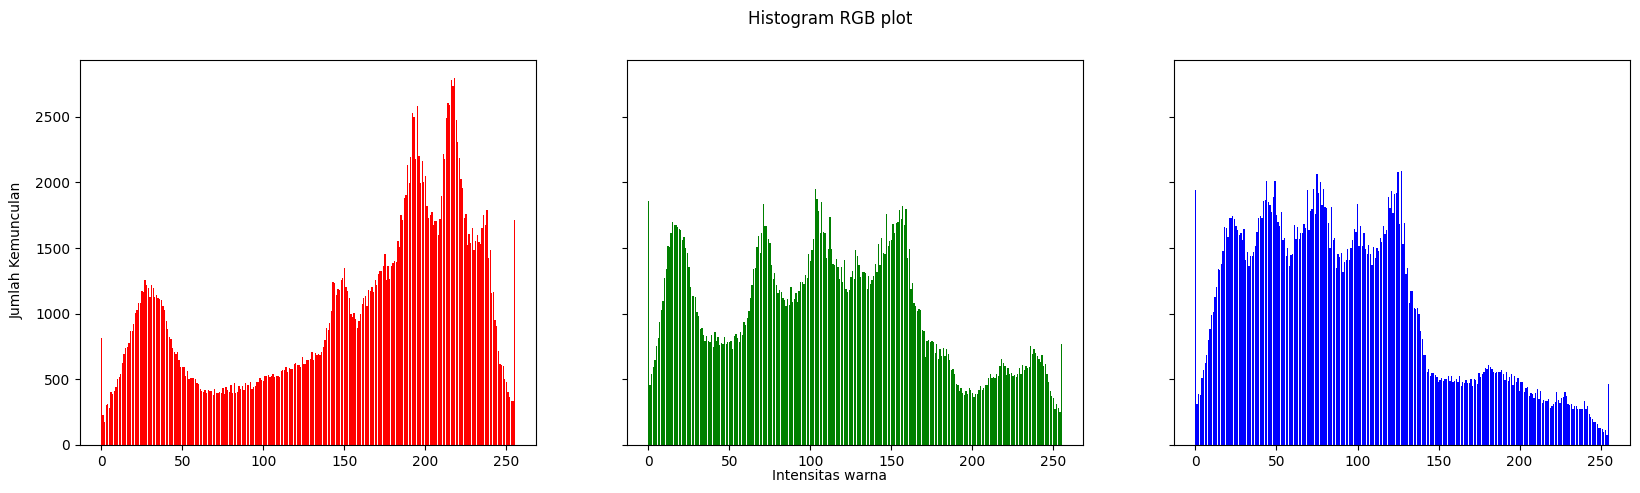

In [3]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

## PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

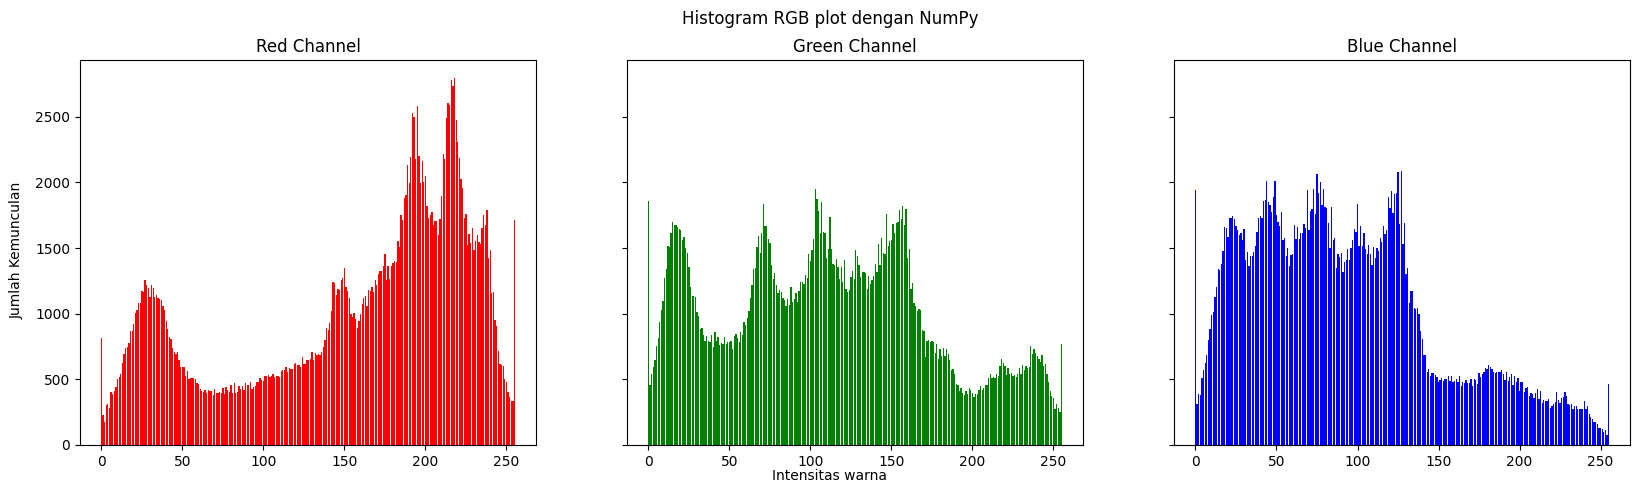

In [4]:
red_hist, red_bin = np.histogram(img[:,:,0].ravel(), bins=256, range=[0,256])
green_hist, green_bin = np.histogram(img[:,:,1].ravel(), bins=256, range=[0,256])
blue_hist, blue_bin = np.histogram(img[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot dengan NumPy')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[0].set_title('Red Channel')

axs[1].bar(names, green_hist, color='green')
axs[1].set_title('Green Channel')

axs[2].bar(names, blue_hist, color='blue')
axs[2].set_title('Blue Channel')
plt.show()

Output yang ditampilkan dengan menggunakan histogram library numpy sama seperti di percobaan.

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.


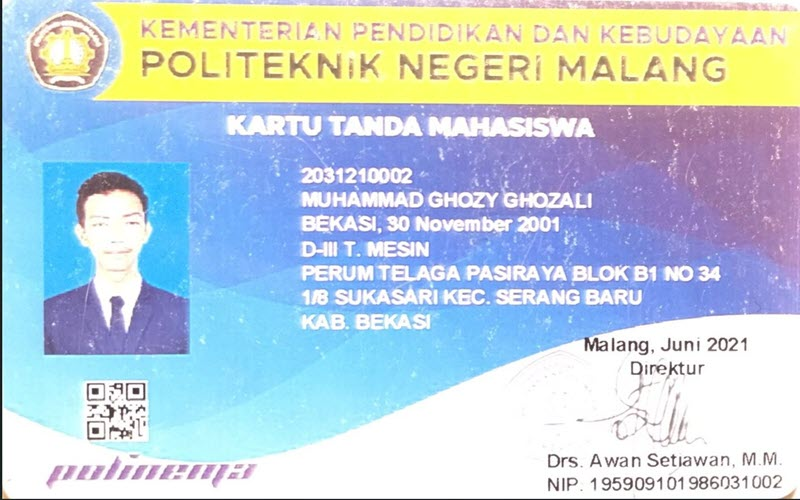

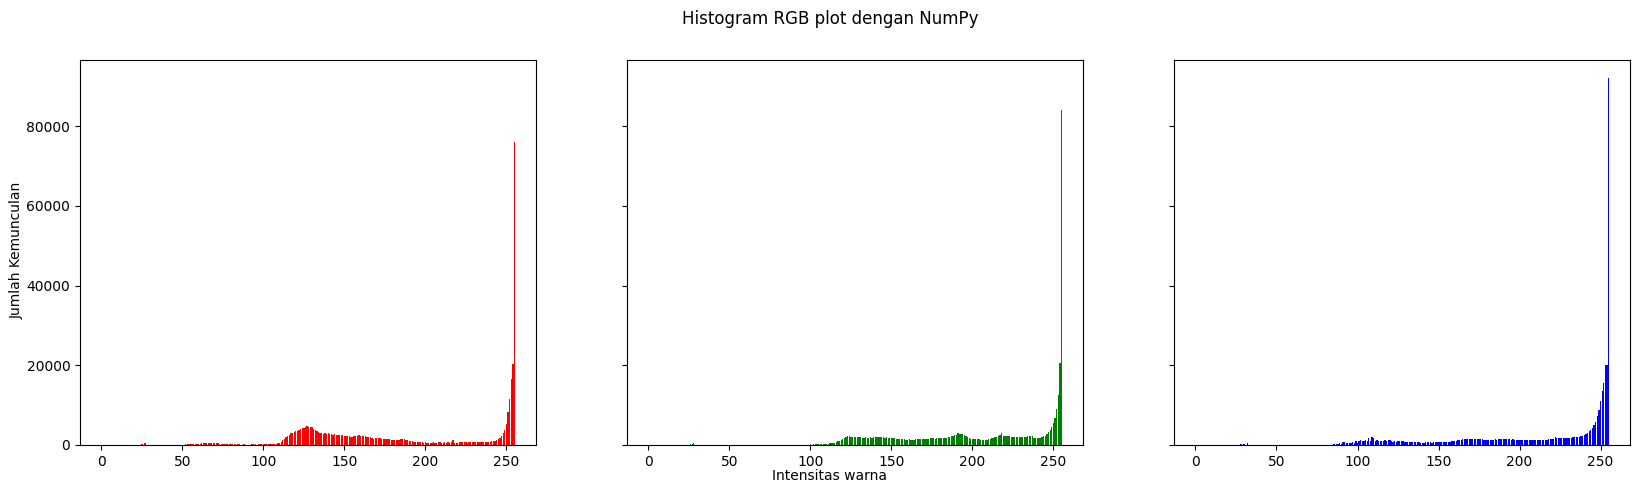

In [5]:
ktm = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/KTMLama.jpg')
ktm_rgb = cv.cvtColor(ktm, cv.COLOR_BGR2RGB)

cv2_imshow(ktm)

height, width, depth = np.shape(ktm_rgb)

ktm_red_hist, ktm_red_bin = np.histogram(ktm_rgb[:,:,0].ravel(), bins=256, range=[0,256])
ktm_green_hist, ktm_green_bin = np.histogram(ktm_rgb[:,:,1].ravel(), bins=256, range=[0,256])
ktm_blue_hist, ktm_blue_bin = np.histogram(ktm_rgb[:,:,2].ravel(), bins=256, range=[0,256])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot dengan NumPy')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, ktm_red_hist, color='red')
axs[1].bar(names, ktm_green_hist, color='green')
axs[2].bar(names, ktm_blue_hist, color='blue')
plt.show()

Dari grafik tersebut. Distribusi piksel mayoritas dari channel berada di sisi kanan karena citra didominasi warna terang. Makanya, citra tersebut cenderung terang.

## D-2 PERCOBAAN HISTOGRAM EQUALIZATION

1. Buatlah histogram citra seperti output histogram equalization dan juga tampilan
gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

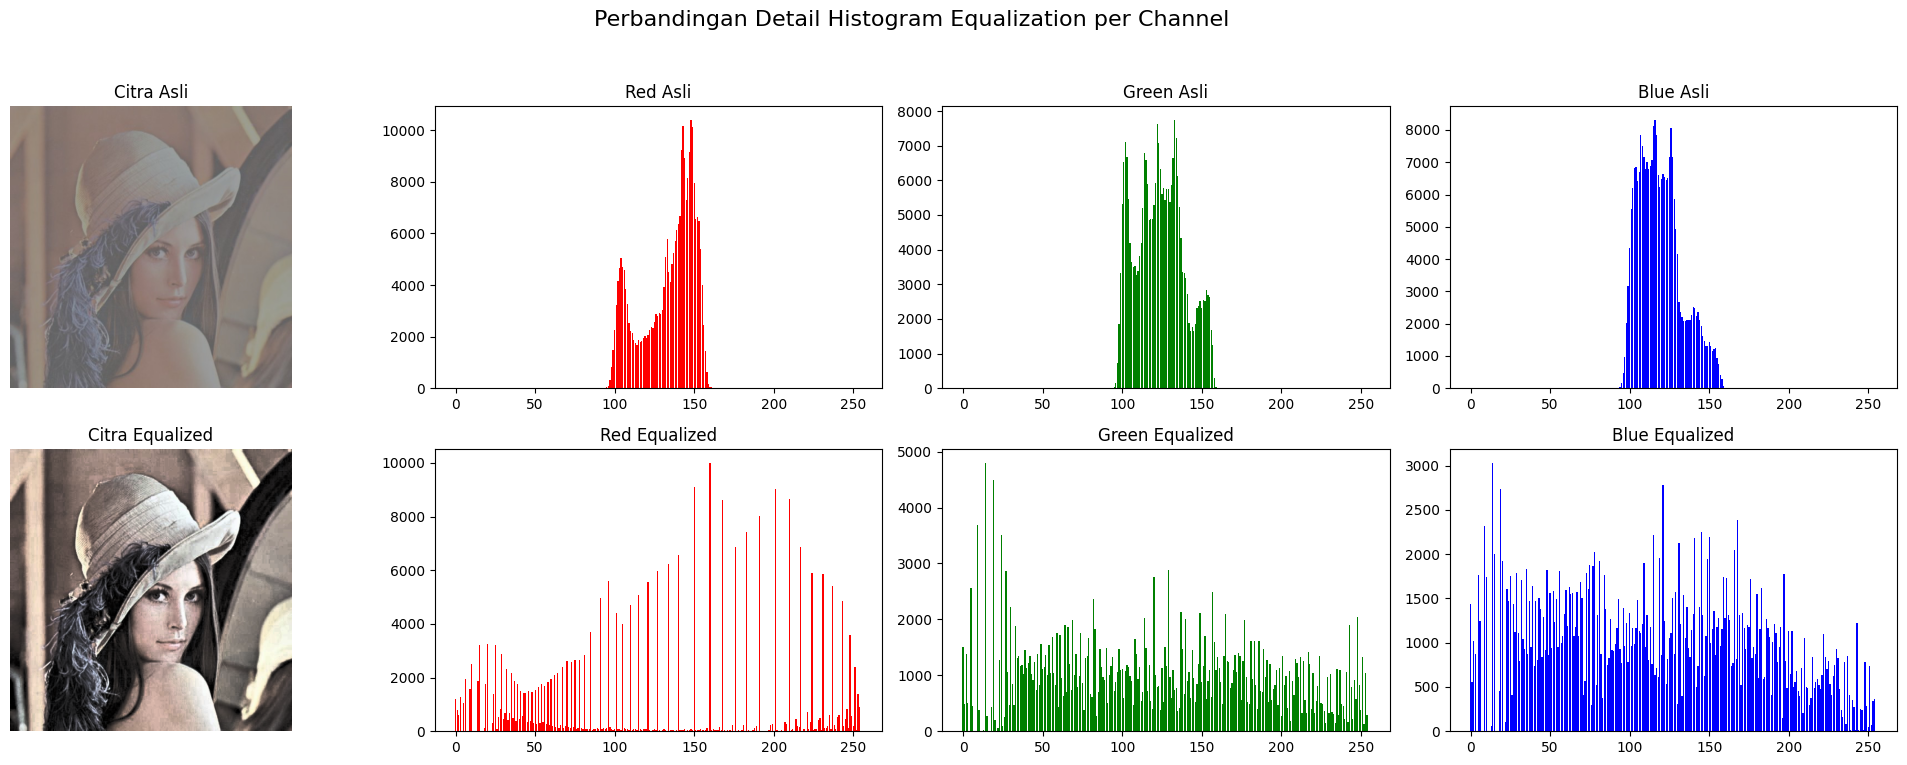

In [6]:
lena = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena_lc.jpg')
lena_rgb = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

# Proses Histogram Equalization (tidak ada perubahan)
lena_hsv = cv.cvtColor(lena_rgb, cv.COLOR_RGB2HSV)
h, s, v = cv.split(lena_hsv)
hist_v, _ = np.histogram(v.ravel(), 256, [0, 256])
cdf_v = np.cumsum(hist_v)
cdf_min = cdf_v.min()
if cdf_min == 0:
  cdf_min = 1

cdf_normalized = ((cdf_v - cdf_min) * 255) / (cdf_v.max() - cdf_min)
transformation_map = cdf_normalized.astype('uint8')
v_equalized = transformation_map[v]
hsv_equalized = cv.merge([h, s, v_equalized])
lena_equalized_rgb = cv.cvtColor(hsv_equalized, cv.COLOR_HSV2RGB)

# 2. Hitung semua histogram yang dibutuhkan (tidak ada perubahan)
red_hist_orig, _ = np.histogram(lena_rgb[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_orig, _ = np.histogram(lena_rgb[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_orig, _ = np.histogram(lena_rgb[:,:,2].ravel(), bins=256, range=[0, 256])

red_hist_eq, _ = np.histogram(lena_equalized_rgb[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_eq, _ = np.histogram(lena_equalized_rgb[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_eq, _ = np.histogram(lena_equalized_rgb[:,:,2].ravel(), bins=256, range=[0, 256])

# 3. Setup Plotting Perbandingan
# PERBAIKAN 1: Mengubah sharey=True menjadi sharey=False (atau menghapusnya)
fig, axs = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
fig.suptitle('Perbandingan Detail Histogram Equalization per Channel', fontsize=16)

# --- BARIS 1: SEBELUM EQUALIZATION ---
axs[0, 0].imshow(lena_rgb)
axs[0, 0].set_title('Citra Asli')
axs[0, 0].axis('off')

names = np.arange(256)
axs[0, 1].bar(names, red_hist_orig, color='red')
axs[0, 1].set_title('Red Asli')
axs[0, 2].bar(names, green_hist_orig, color='green')
axs[0, 2].set_title('Green Asli')
axs[0, 3].bar(names, blue_hist_orig, color='blue')
axs[0, 3].set_title('Blue Asli')

# --- BARIS 2: SESUDAH EQUALIZATION ---
axs[1, 0].imshow(lena_equalized_rgb)
axs[1, 0].set_title('Citra Equalized')
axs[1, 0].axis('off')

axs[1, 1].bar(names, red_hist_eq, color='red')
axs[1, 1].set_title('Red Equalized')
axs[1, 2].bar(names, green_hist_eq, color='green')
axs[1, 2].set_title('Green Equalized')
axs[1, 3].bar(names, blue_hist_eq, color='blue')
axs[1, 3].set_title('Blue Equalized')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.
  
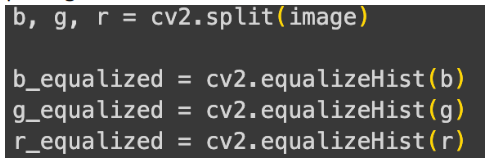

Lengkapi potongan kode tersebut! Bandingkan hasilnya. Apakah output muncul sama?

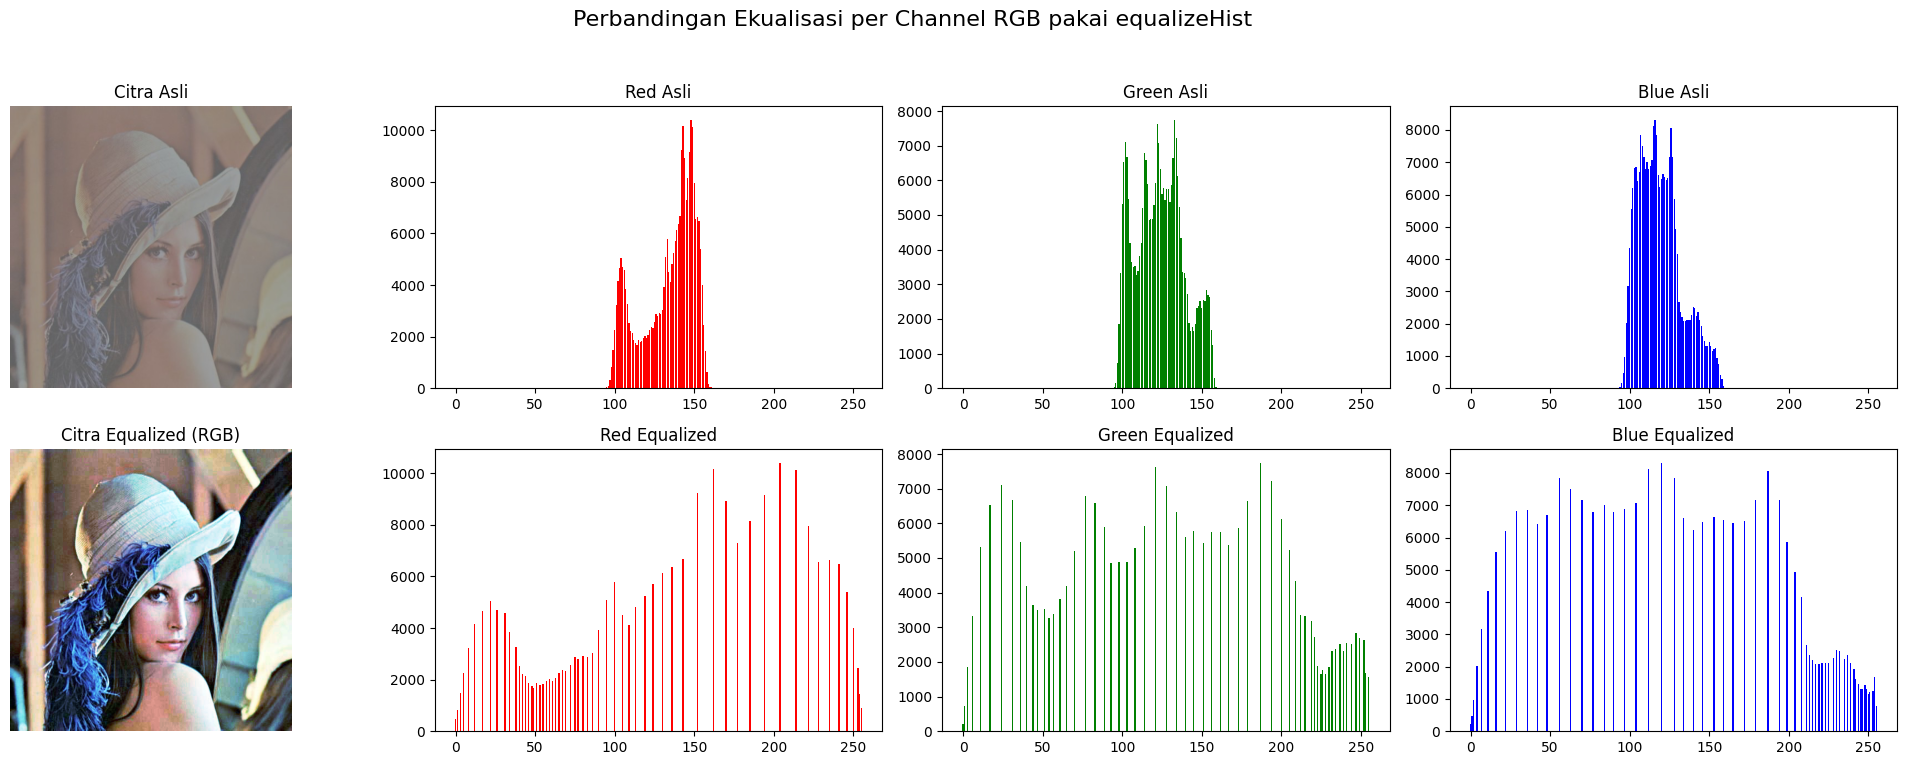

In [7]:
img = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena_lc.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

b, g, r = split = cv.split(img_rgb)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

img_equalized = cv.merge((b_equalized, g_equalized, r_equalized))

# Hitung semua histogram yang dibutuhkan untuk plotting
# Histogram untuk citra asli
red_hist_orig, _ = np.histogram(img_rgb[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_orig, _ = np.histogram(img_rgb[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_orig, _ = np.histogram(img_rgb[:,:,2].ravel(), bins=256, range=[0, 256])

# Histogram untuk citra hasil ekualisasi
red_hist_eq, _ = np.histogram(img_equalized[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_eq, _ = np.histogram(img_equalized[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_eq, _ = np.histogram(img_equalized[:,:,2].ravel(), bins=256, range=[0, 256])

# Setup Plotting Perbandingan
fig, axs = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Perbandingan Ekualisasi per Channel RGB pakai equalizeHist', fontsize=16)

# --- BARIS 1: SEBELUM EQUALIZATION ---
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Citra Asli')
axs[0, 0].axis('off')

names = np.arange(256)
axs[0, 1].bar(names, red_hist_orig, color='red')
axs[0, 1].set_title('Red Asli')
axs[0, 2].bar(names, green_hist_orig, color='green')
axs[0, 2].set_title('Green Asli')
axs[0, 3].bar(names, blue_hist_orig, color='blue')
axs[0, 3].set_title('Blue Asli')

# --- BARIS 2: SESUDAH EQUALIZATION ---
axs[1, 0].imshow(img_equalized)
axs[1, 0].set_title('Citra Equalized (RGB)')
axs[1, 0].axis('off')

axs[1, 1].bar(names, red_hist_eq, color='red')
axs[1, 1].set_title('Red Equalized')
axs[1, 2].bar(names, green_hist_eq, color='green')
axs[1, 2].set_title('Green Equalized')
axs[1, 3].bar(names, blue_hist_eq, color='blue')
axs[1, 3].set_title('Blue Equalized')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Dari hasil histogram, kedua pengolahan tersebut mengeluarkan output yang berbeda. Di pengolahan pertama, distribusinya masih berkumpul di beberapa titik sehingga warnanya menjadi kurang natural. Di pengolahan ini, gambarnya jadi lebih natural dan penyebaran warna tiap piksel lebih merata

## PERTANYAAN PRAKTIKUM D2

**1. Perbandingan Citra Lena**

a. Gunakan hasil histogram equalization pada citra lena.jpg.

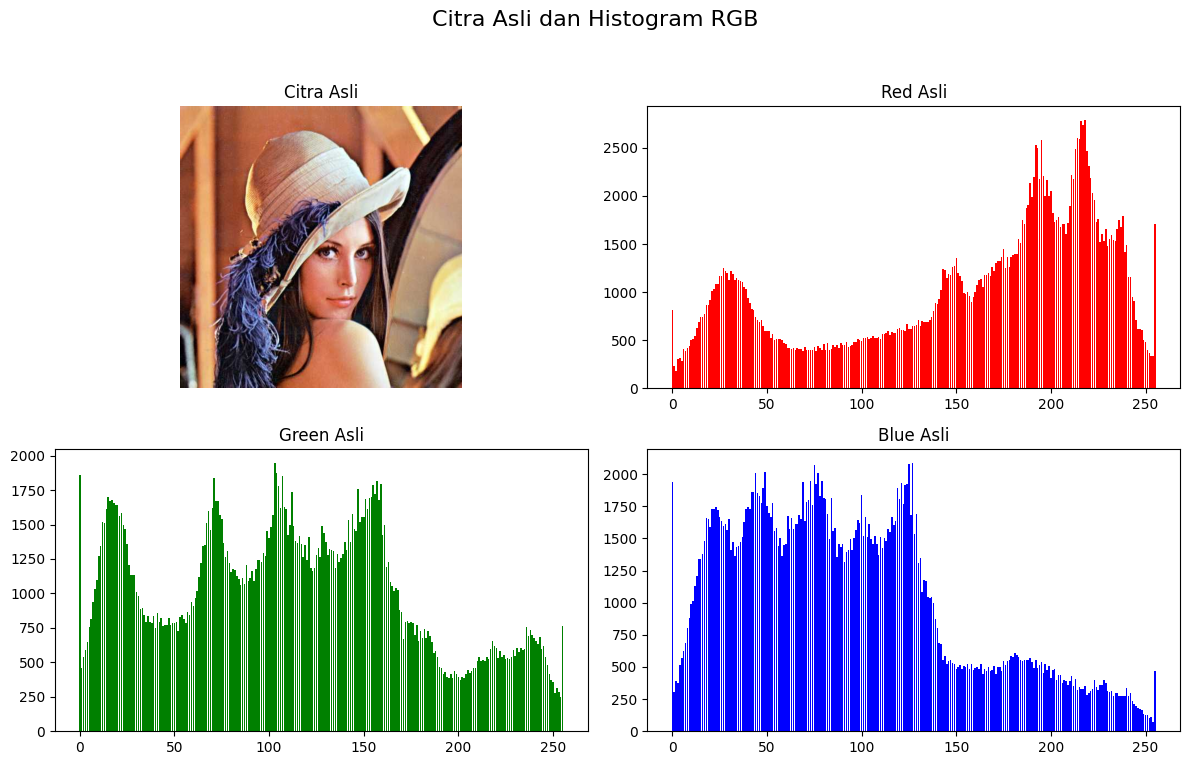

In [8]:
lena = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena.jpg')
lena = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

b, g, r = split = cv.split(lena)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

img_equalized = cv.merge((b_equalized, g_equalized, r_equalized))

# Hitung semua histogram yang dibutuhkan untuk plotting
# Histogram untuk citra asli
red_hist_orig, _ = np.histogram(lena[:,:,0].ravel(), bins=256, range=[0, 256])
green_hist_orig, _ = np.histogram(lena[:,:,1].ravel(), bins=256, range=[0, 256])
blue_hist_orig, _ = np.histogram(lena[:,:,2].ravel(), bins=256, range=[0, 256])

# Setup Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Citra Asli dan Histogram RGB', fontsize=16)

# Plot Citra Asli di posisi (baris 0, kolom 0)
axs[0, 0].imshow(lena)
axs[0, 0].set_title('Citra Asli')
axs[0, 0].axis('off')

names = np.arange(256)
# Plot Histogram Merah di posisi (baris 0, kolom 1)
axs[0, 1].bar(names, red_hist_orig, color='red')
axs[0, 1].set_title('Red Asli')

# Plot Histogram Hijau di posisi (baris 1, kolom 0) <-- DIUBAH
axs[1, 0].bar(names, green_hist_orig, color='green')
axs[1, 0].set_title('Green Asli')

# Plot Histogram Biru di posisi (baris 1, kolom 1) <-- DIUBAH
axs[1, 1].bar(names, blue_hist_orig, color='blue')
axs[1, 1].set_title('Blue Asli')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

In [9]:
if lena.shape == img_equalized.shape:
    psnr_value = cv.PSNR(lena, img_equalized)
    print(f"Nilai PSNR antara citra asli dan citra hasil ekualisasi adalah: {psnr_value:.2f} dB")
else:
    print("Dimensi gambar tidak sama, PSNR tidak dapat dihitung.")

Nilai PSNR antara citra asli dan citra hasil ekualisasi adalah: 17.95 dB


c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas
visual citra? Apakah ada detail baru yang muncul setelah equalization?

Dari hasil PSNR, nilai PSNR tersebut rendah. Artinya, citra hasil equalization lebih buruk dari citra lena. Hal ini dapat terlihat dari perbedaan warna dari img_equalized dengan lena, adanya noise, dan kehilangan detail halus seperti gradasi warna kulit wajah.

**2. Gunakan Citra KTM Lama**

1. Terapkan histogram equalization pada citra KTM lama.jpg.

In [10]:
ktm_lama = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/KTMLama.jpg')
ktm_lama_rgb = cv.cvtColor(ktm_lama, cv.COLOR_BGR2RGB)

r, g, b = cv.split(ktm_lama_rgb)

r_equalized = cv.equalizeHist(r)
g_equalized = cv.equalizeHist(g)
b_equalized = cv.equalizeHist(b)

ktm_lama_equalized = cv.merge((r_equalized, g_equalized, b_equalized))

# 1. Hitung Histogram untuk Citra Asli (RGB)
r_hist_orig, _ = np.histogram(ktm_lama_rgb[:,:,0].ravel(), bins=256, range=[0, 256])
g_hist_orig, _ = np.histogram(ktm_lama_rgb[:,:,1].ravel(), bins=256, range=[0, 256])
b_hist_orig, _ = np.histogram(ktm_lama_rgb[:,:,2].ravel(), bins=256, range=[0, 256])

# 2. Hitung Histogram untuk Citra Hasil Equalization (RGB)
r_hist_eq, _ = np.histogram(ktm_lama_equalized[:,:,0].ravel(), bins=256, range=[0, 256])
g_hist_eq, _ = np.histogram(ktm_lama_equalized[:,:,1].ravel(), bins=256, range=[0, 256])
b_hist_eq, _ = np.histogram(ktm_lama_equalized[:,:,2].ravel(), bins=256, range=[0, 256])

names = np.arange(256)


2. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
dalam satu layout.


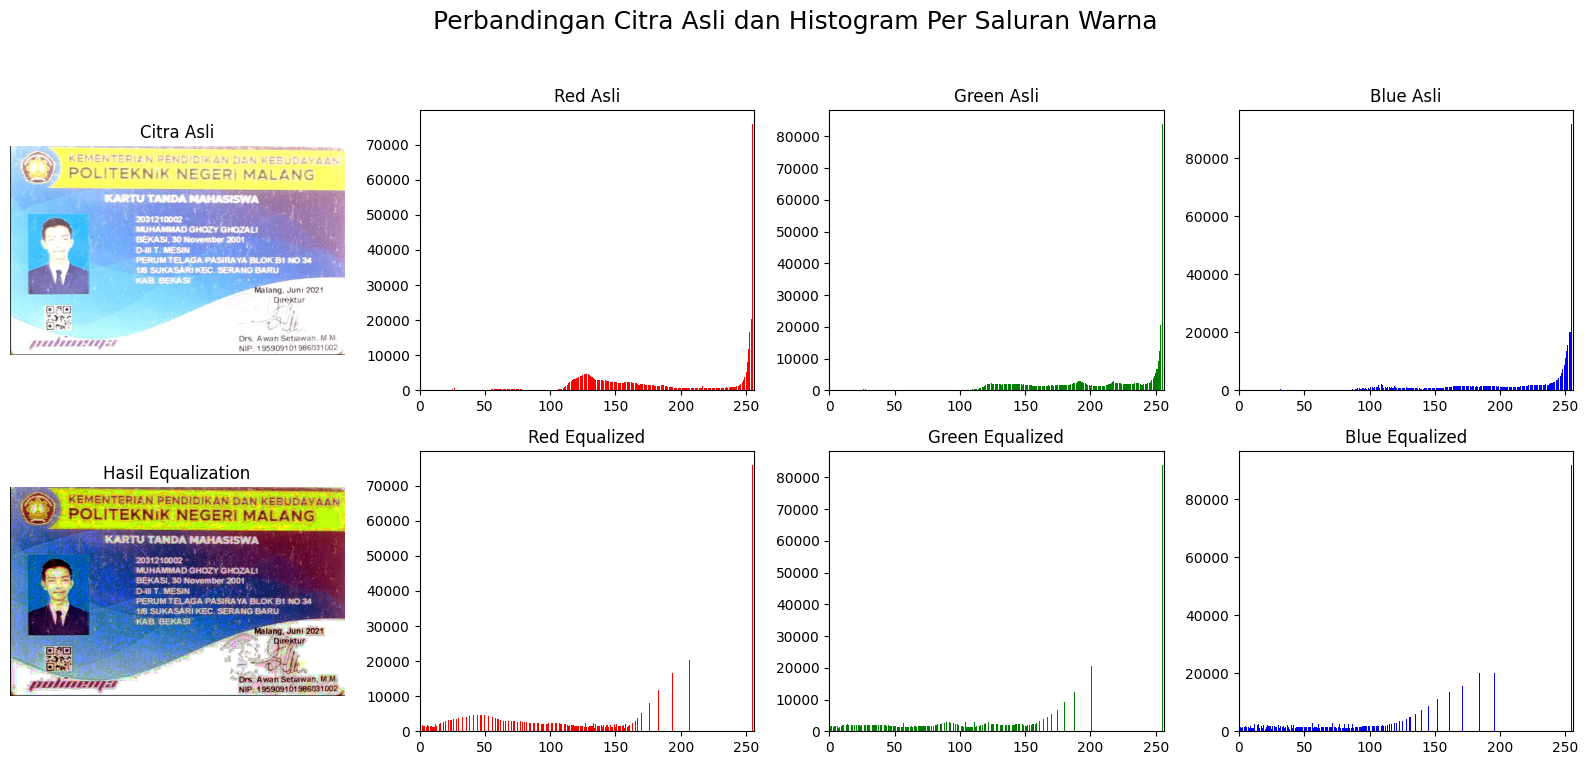

In [11]:
plt.figure(figsize=(16, 8))
plt.suptitle('Perbandingan Citra Asli dan Histogram Per Saluran Warna', fontsize=18)

# 1. Plot Citra Asli
plt.subplot(2, 4, 1)
plt.imshow(ktm_lama_rgb)
plt.title('Citra Asli')
plt.axis('off')

# 2. Plot Histogram Merah Asli
plt.subplot(2, 4, 2)
plt.bar(names, r_hist_orig, color='red')
plt.title('Red Asli')
plt.xlim([0, 256])

# 3. Plot Histogram Hijau Asli
plt.subplot(2, 4, 3)
plt.bar(names, g_hist_orig, color='green')
plt.title('Green Asli')
plt.xlim([0, 256])

# 4. Plot Histogram Biru Asli
plt.subplot(2, 4, 4)
plt.bar(names, b_hist_orig, color='blue')
plt.title('Blue Asli')
plt.xlim([0, 256])

# 5. Plot Citra Hasil Equalization
plt.subplot(2, 4, 5)
plt.imshow(ktm_lama_equalized)
plt.title('Hasil Equalization')
plt.axis('off')

# 6. Plot Histogram Merah Hasil Equalization
plt.subplot(2, 4, 6)
plt.bar(names, r_hist_eq, color='red')
plt.title('Red Equalized')
plt.xlim([0, 256])
# Analisis: Histogram harus terlihat lebih merata atau menyebar

# 7. Plot Histogram Hijau Hasil Equalization
plt.subplot(2, 4, 7)
plt.bar(names, g_hist_eq, color='green')
plt.title('Green Equalized')
plt.xlim([0, 256])

# 8. Plot Histogram Biru Hasil Equalization
plt.subplot(2, 4, 8)
plt.bar(names, b_hist_eq, color='blue')
plt.title('Blue Equalized')
plt.xlim([0, 256])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

3. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas
informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

Dari hasil pengolahan tersebut, ada banyak perubahan detail pada citra setelah dilakukan equalized seperti :

* kontrasnya jadi lebih tinggi sehingga lebih jelas
* detail foto menjadi lebih terlihat seperti rambut dan jas, tapi tekstur kulitnya jadi terlihat kasar
* teks dari citra jadi terlihat jelas dan lebih tegas
* warna latarnya dari pudar dan lembut menjadi tegas, tapi warna birunya bergeser ke warna biru keunguan atau kehijauan.

## TUGAS PRAKTIKUM D3

1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

In [13]:
lena_img = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena.jpg')
lena_img_rgb = cv.cvtColor(lena_img, cv.COLOR_BGR2RGB)

# Konversi BGR ke Grayscale (diperlukan untuk 1-bit dithering)
citra_gray = cv.cvtColor(lena_img_rgb, cv.COLOR_BGR2GRAY)

# Konversi ke tipe float untuk perhitungan error yang akurat
img_float = citra_gray.astype(float)
height, width = img_float.shape

# dapatkan ukuran
img_float = citra_gray.copy().astype(float)
height, width = img_float.shape

In [14]:
# Algoritma Dithering Floyd-Steinberg

for y in range(height-1):
  for x in range(1, width-1):
    # ambil nilai piksel lama
    old_pixel = img_float[y,x]

    # kuantisasi piksel : bulatkan ke nilai terdekat (0 atau 255)
    new_pixel = 255 if old_pixel > 128 else 0
    img_float[y,x] = new_pixel

    # hitung error kuantisasi
    error = old_pixel - new_pixel

    # sebarkan galat ke piksel tetangga
    img_float[y,x+1] += error * 7/16
    img_float[y+1,x-1] += error * 3/16
    img_float[y+1,x] += error * 5/16
    img_float[y+1,x+1] += error * 1/16

# konversi array float ke tipe integer
gambar_dithered = img_float.astype(np.uint8)

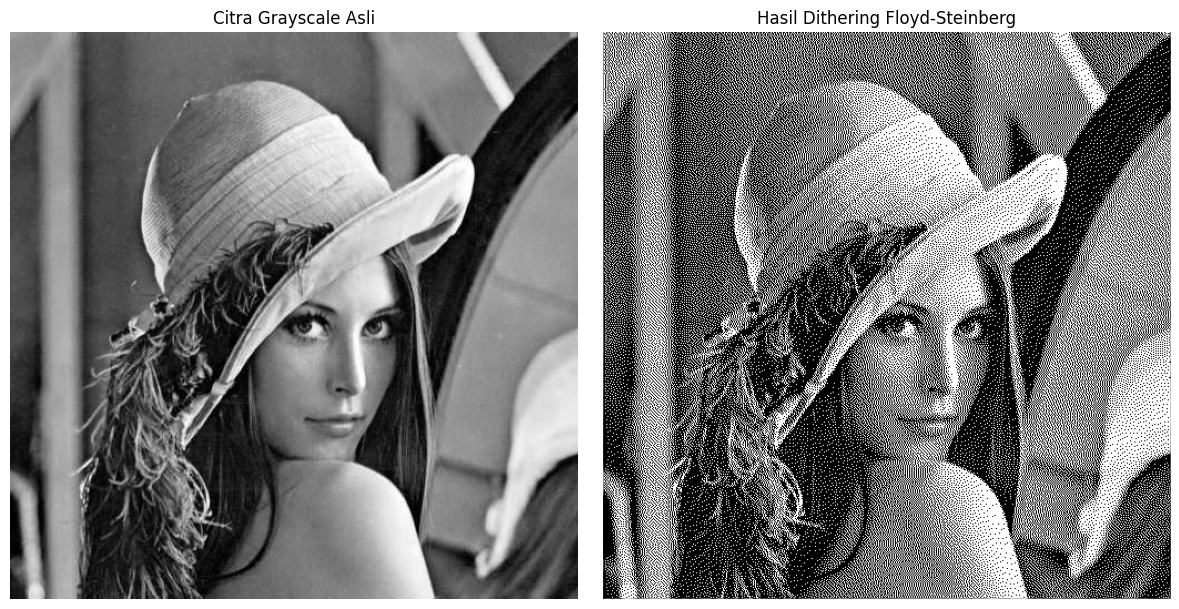

In [15]:
# visualisasi hasil

# Atur ukuran plot agar lebih besar
plt.figure(figsize=(12, 6))

# Tampilkan citra grayscale asli
plt.subplot(1, 2, 1)
plt.imshow(citra_gray, cmap='gray')
plt.title('Citra Grayscale Asli')
plt.axis('off') # Menghilangkan sumbu x dan y

# Tampilkan citra hasil dithering
plt.subplot(1, 2, 2)
plt.imshow(gambar_dithered, cmap='gray')
plt.title('Hasil Dithering Floyd-Steinberg')
plt.axis('off')

# Menampilkan plot
plt.tight_layout()
plt.show()

2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!


In [31]:
lena_lc = cv.imread('/content/drive/MyDrive/PCVK25_3F_15/image/lena_lc.jpg')
lena_lc_gray = cv.cvtColor(lena_lc, cv.COLOR_BGR2GRAY)

lena_lc_eq = cv.equalizeHist(lena_lc_gray)

img_float = lena_lc_eq.copy().astype(float)
height, width = img_float.shape

In [33]:
# fungsi ordered dithering
def ordered_dithering(image_gray, threshold_matrix):
    height, width = image_gray.shape
    matrix_h, matrix_w = threshold_matrix.shape

    dithered_image = np.zeros_like(image_gray, dtype=np.uint8)

    for y in range(height):
        for x in range(width):
            threshold_val = threshold_matrix[y % matrix_h, x % matrix_w]
            pixel_val = image_gray[y, x]

            if pixel_val / 255.0 > threshold_val:
                dithered_image[y, x] = 255
            else:
                dithered_image[y, x] = 0

    return dithered_image

# Algoritma Dithering Floyd-Steinberg

for y in range(height-1):
  for x in range(1, width-1):
    # ambil nilai piksel lama
    old_pixel = img_float[y,x]

    # kuantisasi piksel : bulatkan ke nilai terdekat (0 atau 255)
    new_pixel = 255 if old_pixel > 128 else 0
    img_float[y,x] = new_pixel

    # hitung error kuantisasi
    error = old_pixel - new_pixel

    # sebarkan galat ke piksel tetangga
    img_float[y,x+1] += error * 7/16
    img_float[y+1,x-1] += error * 3/16
    img_float[y+1,x] += error * 5/16
    img_float[y+1,x+1] += error * 1/16

# konversi array float ke tipe integer
gambar_dithered = img_float.astype(np.uint8)

bayer_8x8 = np.array([
    [ 0, 32,  8, 40,  2, 34, 10, 42],
    [48, 16, 56, 24, 50, 18, 58, 26],
    [12, 44,  4, 36, 14, 46,  6, 38],
    [60, 28, 52, 20, 62, 30, 54, 22],
    [ 3, 35, 11, 43,  1, 33,  9, 41],
    [51, 19, 59, 27, 49, 17, 57, 25],
    [15, 47,  7, 39, 13, 45,  5, 37],
    [63, 31, 55, 23, 61, 29, 53, 21]
])
bayer_8x8_normalized = bayer_8x8 / 64.0
visualisasi_intensitas = ordered_dithering(lena_lc_eq, bayer_8x8_normalized)

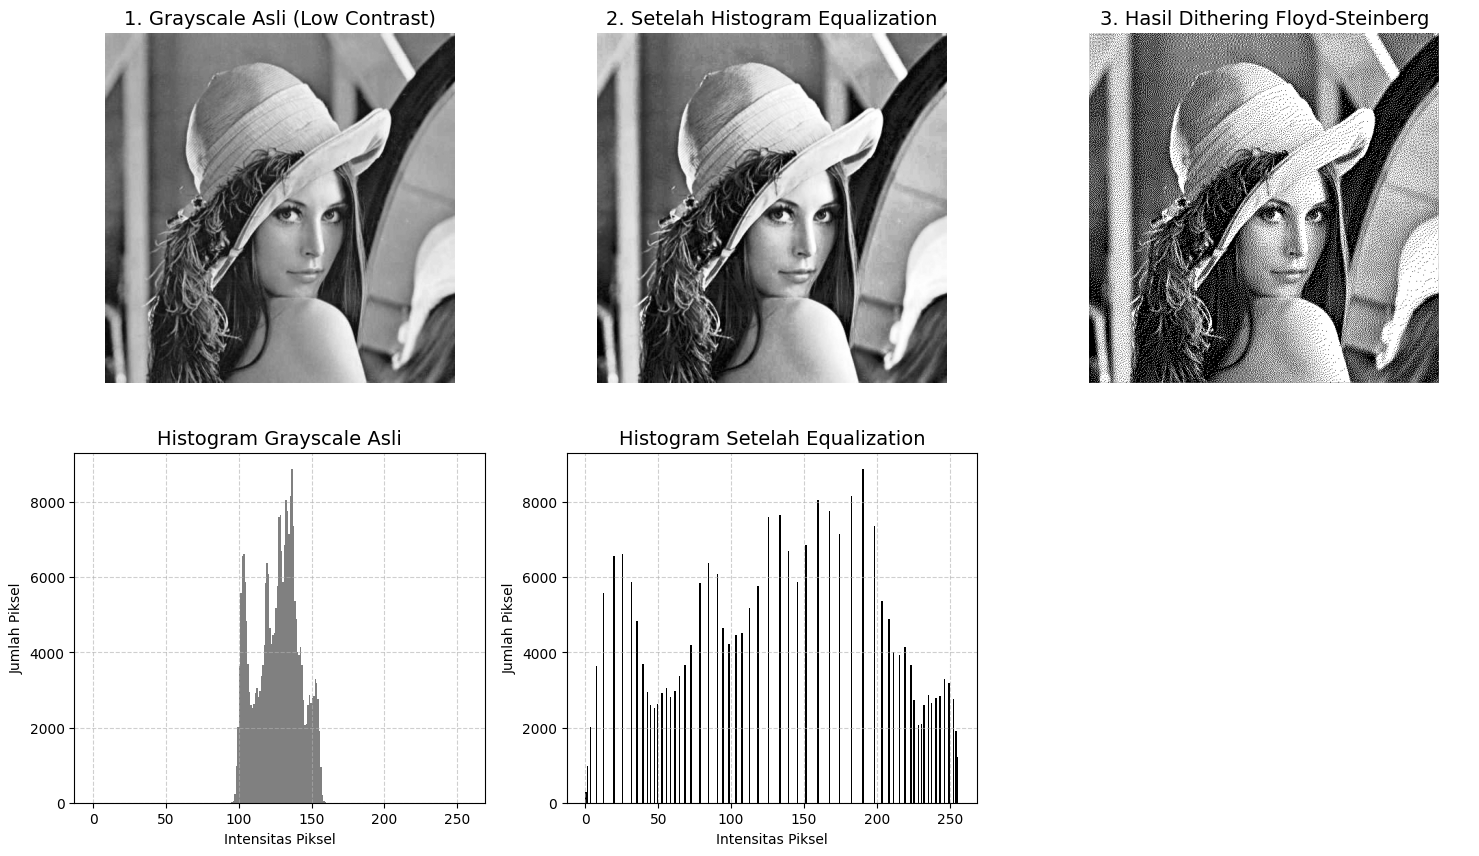

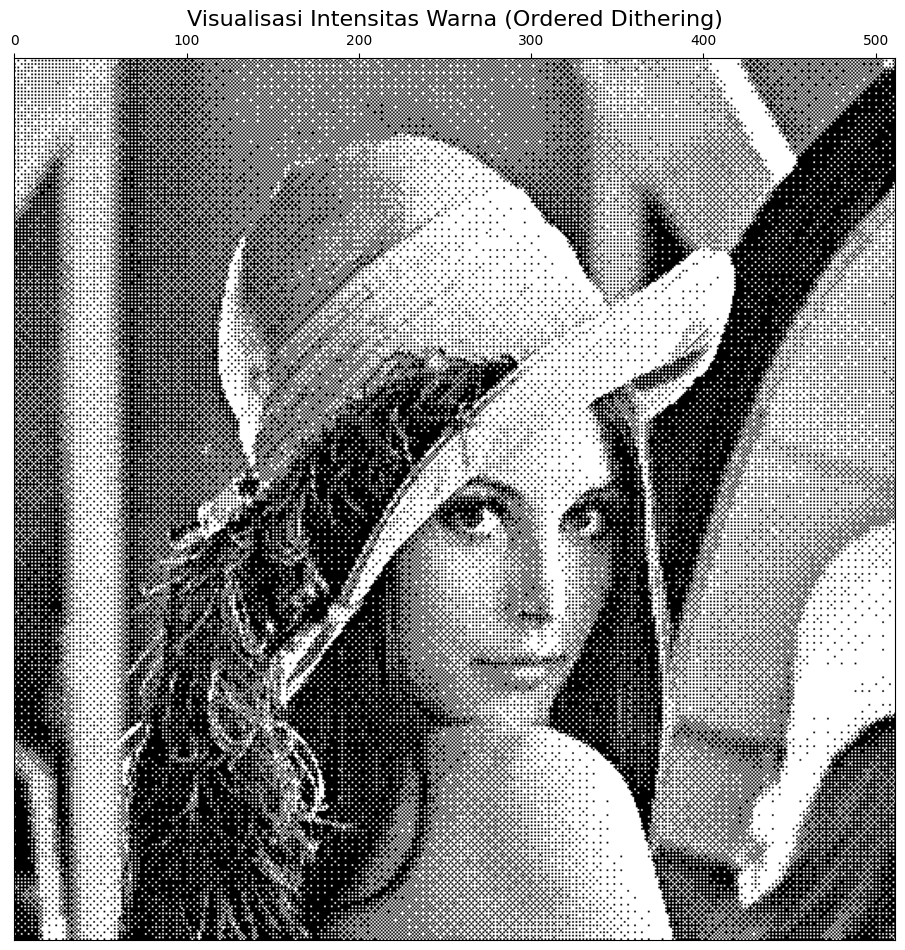

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- BARIS 1: TAHAPAN CITRA ---

# Plot 1: Gambar Grayscale Asli (Low Contrast)
axes[0, 0].imshow(lena_lc_gray, cmap='gray')
axes[0, 0].set_title('1. Grayscale Asli (Low Contrast)', fontsize=14)
axes[0, 0].axis('off')

# Plot 2: Gambar Setelah Histogram Equalization
axes[0, 1].imshow(lena_lc_eq, cmap='gray')
axes[0, 1].set_title('2. Setelah Histogram Equalization', fontsize=14)
axes[0, 1].axis('off')

# Plot 3: Hasil Akhir Dithering Floyd-Steinberg
axes[0, 2].imshow(gambar_dithered, cmap='gray')
axes[0, 2].set_title('3. Hasil Dithering Floyd-Steinberg', fontsize=14)
axes[0, 2].axis('off')

# --- BARIS 2: ANALISIS HISTOGRAM (INTENSITAS WARNA) ---

# Plot 4: Histogram dari Gambar Grayscale Asli
axes[1, 0].hist(lena_lc_gray.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 0].set_title('Histogram Grayscale Asli', fontsize=14)
axes[1, 0].set_xlabel('Intensitas Piksel')
axes[1, 0].set_ylabel('Jumlah Piksel')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Plot 5: Histogram dari Gambar Setelah Equalization
axes[1, 1].hist(lena_lc_eq.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 1].set_title('Histogram Setelah Equalization', fontsize=14)
axes[1, 1].set_xlabel('Intensitas Piksel')
axes[1, 1].set_ylabel('Jumlah Piksel')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Plot 6: Kosong (tidak digunakan)
# Kita sembunyikan plot terakhir yang tidak terpakai agar rapi
axes[1, 2].axis('off')

# --- Tampilkan Visualisasi Intensitas Warna secara terpisah (ukuran besar) ---
plt.figure(figsize=(10, 10))
plt.imshow(visualisasi_intensitas, cmap='gray')
plt.title('Visualisasi Intensitas Warna (Ordered Dithering)', fontsize=16)
plt.axis('on') # Biarkan sumbu terlihat jika ini yang Anda inginkan
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,
                left=False, labelleft=False, right=False, labelright=False)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # rect disesuaikan agar suptitle tidak overlap
plt.show()
